In [11]:
# ==============================================================================
# 1. IMPORT LIBRARIES 
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
from pathlib import Path

load_dotenv(dotenv_path=Path('etl/.env'))

warnings.filterwarnings('ignore')

# Modelos de scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
)

# Los 8 Modelos a comparar
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Preprocesamiento
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Todas las librerías cargadas correctamente.")

Todas las librerías cargadas correctamente.


In [12]:
# Cargar variables de entorno
load_dotenv()
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
db = os.getenv('DB_NAME')

# Conectar y extraer
engine = create_engine(f'postgresql://{user}:{password}@{host}:{port}/{db}')
query = "SELECT * FROM dw_inventario_predictivo"
df = pd.read_sql(query, engine)

print("============================================================")
print("CARGANDO DATASET DE QUIEBRES DE STOCK (MERCADOS LA COLINA)")
print("============================================================")
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print("\nDistribución de la variable target (quiebre_stock):")
print(df['quiebre_stock'].value_counts())
print(f"\nTasa de quiebre global: {(df['quiebre_stock'].mean() * 100):.2f}%")

CARGANDO DATASET DE QUIEBRES DE STOCK (MERCADOS LA COLINA)
Dimensiones: 14258 filas × 18 columnas

Distribución de la variable target (quiebre_stock):
quiebre_stock
0    9239
1    5019
Name: count, dtype: int64

Tasa de quiebre global: 35.20%


In [13]:
# 1. Separar features (X) y target (y)
# Eliminamos IDs y Fechas porque causan Data Leakage (sobreajuste)
columnas_a_eliminar = ['id_producto_tienda_semana', 'inicio_semana', 'quiebre_stock']
X = df.drop(columns=columnas_a_eliminar, errors='ignore')
y = df['quiebre_stock']

# 2. Convertir variables categóricas a números (One-Hot Encoding)
columnas_texto = X.select_dtypes(include=['object']).columns.tolist()
if columnas_texto:
    X = pd.get_dummies(X, columns=columnas_texto, drop_first=True)

# 3. División Train/Test (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Escalado (Vital para Regresión Logística, KNN y SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset listo: {X_train.shape[0]} registros para entrenar, {X_test.shape[0]} para probar.")
print(f"Total de Features (Variables predictoras): {X.shape[1]}")

Dataset listo: 11406 registros para entrenar, 2852 para probar.
Total de Features (Variables predictoras): 30


In [14]:
# Calcular ratio de desbalance para ayudar a los modelos de árboles
ratio = (y_train == 0).sum() / (y_train == 1).sum()

modelos = {
    '1. Regresión Logística': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    '2. Árbol de Decisión': DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    '3. Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    '4. XGBoost': XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.05, scale_pos_weight=ratio, random_state=42, eval_metric='auc'),
    '5. LightGBM': LGBMClassifier(n_estimators=500, max_depth=5, learning_rate=0.05, scale_pos_weight=ratio, random_state=42, verbose=-1),
    '6. KNN (k=10)': KNeighborsClassifier(n_neighbors=10, weights='distance', n_jobs=-1),
    '7. Naive Bayes': GaussianNB(),
    '8. SVM (RBF)': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
}

print(f"{len(modelos)} modelos configurados y listos para competir.")

8 modelos configurados y listos para competir.


In [15]:
resultados = []

print("=" * 80)
print("ENTRENANDO Y EVALUANDO TODOS LOS MODELOS")
print("=" * 80)

for nombre, modelo in modelos.items():
    print(f"\nEntrenando {nombre}...")
    inicio = time.time()
    
    try:
        # Usar datos escalados para modelos matemáticos espaciales
        if nombre in ['1. Regresión Logística', '6. KNN (k=10)', '8. SVM (RBF)']:
            X_tr, X_te = X_train_scaled, X_test_scaled
        else:
            X_tr, X_te = X_train, X_test
        
        # Entrenar
        modelo.fit(X_tr, y_train)
        
        # Predecir
        y_pred = modelo.predict(X_te)
        y_pred_proba = modelo.predict_proba(X_te)[:, 1]
        
        # Métricas
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)
        
        # Cross-validation (5-fold)
        cv_scores = cross_val_score(modelo, X_tr, y_train, cv=5, scoring='roc_auc')
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
        
        tiempo = time.time() - inicio
        
        resultados.append({
            'Modelo': nombre, 'Accuracy': accuracy, 'Precision': precision, 
            'Recall': recall, 'F1-Score': f1, 'ROC-AUC': auc, 
            'CV ROC-AUC': cv_mean, 'CV Std': cv_std, 'Tiempo (s)': tiempo
        })
        
        print(f"   Accuracy: {accuracy:.3f} | AUC: {auc:.3f} | CV-AUC: {cv_mean:.3f}±{cv_std:.3f}")
        print(f"   Tiempo: {tiempo:.2f}s")
        
    except Exception as e:
        print(f"   ❌ Error: {e}")

df_resultados = pd.DataFrame(resultados).sort_values('ROC-AUC', ascending=False)
print("=" * 100)
print("TABLA COMPARATIVA DE MODELOS (Ordenada por ROC-AUC)")
print("=" * 100)
display(df_resultados)

ENTRENANDO Y EVALUANDO TODOS LOS MODELOS

Entrenando 1. Regresión Logística...
   Accuracy: 0.620 | AUC: 0.674 | CV-AUC: 0.674±0.013
   Tiempo: 0.16s

Entrenando 2. Árbol de Decisión...
   Accuracy: 0.580 | AUC: 0.625 | CV-AUC: 0.629±0.013
   Tiempo: 0.21s

Entrenando 3. Random Forest...
   Accuracy: 0.611 | AUC: 0.661 | CV-AUC: 0.659±0.011
   Tiempo: 3.54s

Entrenando 4. XGBoost...
   Accuracy: 0.612 | AUC: 0.657 | CV-AUC: 0.644±0.009
   Tiempo: 4.81s

Entrenando 5. LightGBM...
   Accuracy: 0.614 | AUC: 0.656 | CV-AUC: 0.644±0.011
   Tiempo: 3.11s

Entrenando 6. KNN (k=10)...
   Accuracy: 0.623 | AUC: 0.606 | CV-AUC: 0.602±0.012
   Tiempo: 0.25s

Entrenando 7. Naive Bayes...
   Accuracy: 0.628 | AUC: 0.648 | CV-AUC: 0.660±0.012
   Tiempo: 0.06s

Entrenando 8. SVM (RBF)...
   Accuracy: 0.608 | AUC: 0.658 | CV-AUC: 0.650±0.011
   Tiempo: 87.40s
TABLA COMPARATIVA DE MODELOS (Ordenada por ROC-AUC)


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV ROC-AUC,CV Std,Tiempo (s)
0,1. Regresión Logística,0.620266,0.469592,0.607570,0.529744,0.673686,0.673938,0.012753,0.162594
2,3. Random Forest,0.610799,0.461760,0.637450,0.535565,0.660973,0.658993,0.010831,3.535943
7,8. SVM (RBF),0.607994,0.460028,0.653386,0.539918,0.657889,0.649607,0.011303,87.400622
3,4. XGBoost,0.611851,0.460717,0.601594,0.521814,0.657302,0.643542,0.008693,4.805264
4,5. LightGBM,0.613955,0.463941,0.621514,0.531290,0.656157,0.643572,0.010798,3.110595
6,7. Naive Bayes,0.627980,0.474890,0.536853,0.503974,0.647756,0.660097,0.011750,0.064091
1,2. Árbol de Decisión,0.579944,0.436767,0.667331,0.527975,0.625449,0.628747,0.013100,0.205277
5,6. KNN (k=10),0.622721,0.447826,0.307769,0.364817,0.606141,0.601981,0.011519,0.253931


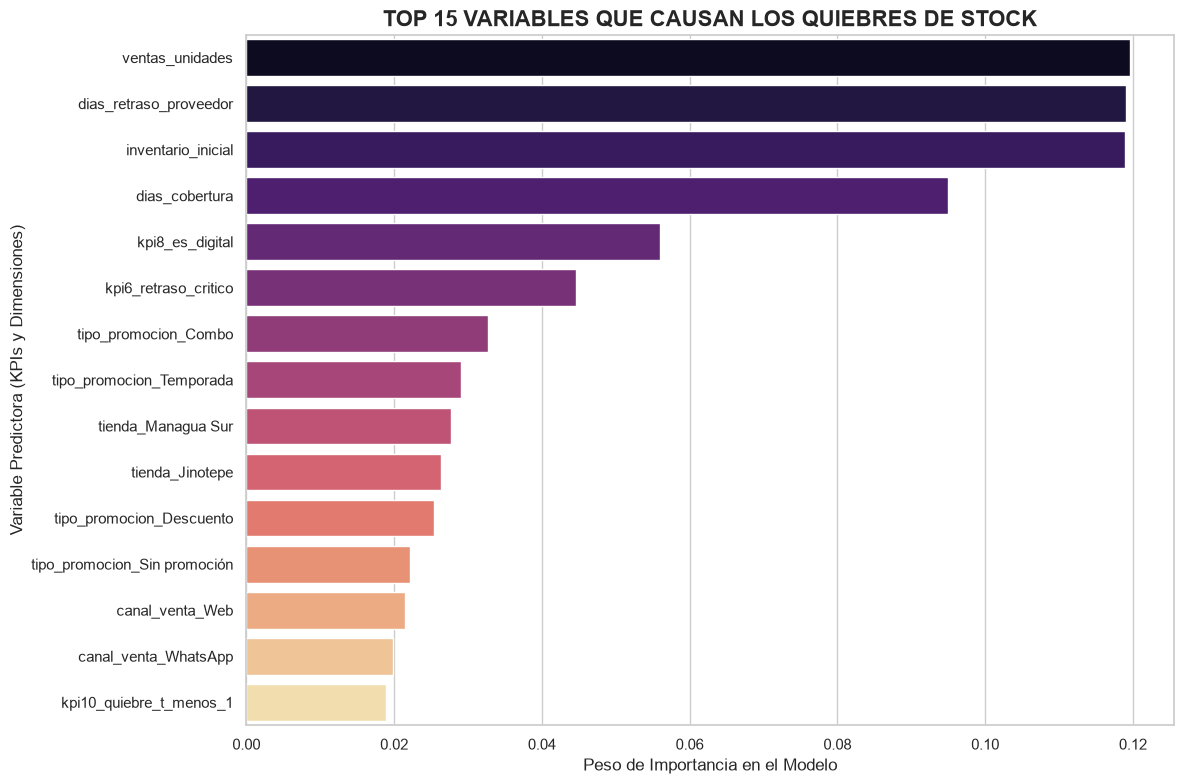

CONCLUSIÓN DE NEGOCIO:
La variable que más detona los quiebres de stock es: 'ventas_unidades'.
Esto demuestra que la Minería de Datos va más allá del BI tradicional, encontrando la verdadera causa raíz.


In [ ]:
modelo_arbol = modelos['3. Random Forest'] 

# Obtener el peso (importancia) de cada variable
importancias = modelo_arbol.feature_importances_
features = X.columns

# Crear un DataFrame para ordenarlas
df_importancia = pd.DataFrame({
    'Variable': features,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Graficar
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Variable', data=df_importancia.head(15), palette='magma')
plt.title('TOP 15 VARIABLES QUE CAUSAN LOS QUIEBRES DE STOCK', fontsize=16, fontweight='bold')
plt.xlabel('Peso de Importancia en el Modelo', fontsize=12)
plt.ylabel('Variable Predictora (KPIs y Dimensiones)', fontsize=12)
plt.tight_layout()
plt.show()

# Imprimir la conclusión
print("CONCLUSIÓN DE NEGOCIO:")
print(f"La variable que más detona los quiebres de stock es: '{df_importancia.iloc[0]['Variable']}'.")
print("Esto demuestra que la Minería de Datos va más allá del BI tradicional, encontrando la verdadera causa raíz.")